# Modelo Preditivo de Risco de Defasagem — Pergunta 9
### Datathon Passos Mágicos · FIAP PósTech DTAT · Fase 5

**Objetivo (sistema de alerta precoce):** dado o retrato de um aluno no ano N, estimar a
probabilidade de ele estar **defasado no ano N+1** — para a Passos Mágicos priorizar intervenção
*antes* da queda.

**Etapas exigidas:** feature engineering · split treino/teste · modelagem · avaliação.

**Três decisões de projeto (validadas na EDA e na discussão da turma):**
1. **Split temporal** — treina em pares 2022→2023, testa em 2023→2024 (simula o uso real).
2. **IAN excluído** — é função determinística da defasagem (redundante); INDE/Pedra e Mat/Por/Ing também saem (redundantes).
3. **IPP excluído / nulos nativos** — IPP é estruturalmente ausente em 2022; usamos HistGradientBoosting, que lida com nulos sem imputação artificial.

In [1]:
import sys; sys.path.append('../src')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'figure.dpi':110,'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
ROXO,VERDE,VERM,AMAR,AZUL='#6b4e9e','#2a9d8f','#e76f51','#e9c46a','#264653'
from modelo import prepara_dados, split_temporal, novo_modelo, FEATURES, TARGET
df=prepara_dados(); print('Pares de modelagem:',len(df)); print('Features:',FEATURES)

Pares de modelagem: 1365
Features: ['idade', 'fase_num', 'genero_bin', 'ano_ingresso', 'defasagem', 'ida', 'ieg', 'iaa', 'ips', 'ipv']


## 1. Feature engineering e split temporal
A engenharia de atributos central deste problema é a **construção longitudinal**: cada linha une as
features do aluno no ano N ao seu desfecho no ano N+1. Isso transforma um dado transversal num
problema preditivo de horizonte.

In [2]:
Xtr,ytr,Xte,yte=split_temporal(df)
print(f'Treino (2022→2023): {len(Xtr)} | prevalência risco = {ytr.mean():.1%}')
print(f'Teste  (2023→2024): {len(Xte)} | prevalência risco = {yte.mean():.1%}')
print('\nNulos por feature (HGB trata nativamente):'); print(df[FEATURES].isna().sum().to_dict())

Treino (2022→2023): 600 | prevalência risco = 61.0%
Teste  (2023→2024): 765 | prevalência risco = 40.3%

Nulos por feature (HGB trata nativamente):
{'idade': 304, 'fase_num': 0, 'genero_bin': 0, 'ano_ingresso': 0, 'defasagem': 0, 'ida': 72, 'ieg': 72, 'iaa': 59, 'ips': 62, 'ipv': 72}


*Nota:* treino e teste têm prevalências diferentes (61% vs 40%) — há **deslocamento real entre
coortes**. O teste temporal é, portanto, o cenário honesto e mais difícil.

## 2. Modelagem e comparação
Comparamos um baseline, Regressão Logística (linear, interpretável) e HistGradientBoosting.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer; from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression; from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, classification_report, confusion_matrix
base=DummyClassifier(strategy='most_frequent').fit(Xtr,ytr)
logit=Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler()),
                ('c',LogisticRegression(max_iter=1000,class_weight='balanced'))]).fit(Xtr,ytr)
hgb=novo_modelo().fit(Xtr,ytr)
res={}
for nm,mdl in [('Baseline',base),('Reg. Logística',logit),('HistGradientBoosting',hgb)]:
    p=mdl.predict_proba(Xte)[:,1] if hasattr(mdl,'predict_proba') else mdl.predict(Xte)
    res[nm]=(roc_auc_score(yte,p),average_precision_score(yte,p),p)
pd.DataFrame({k:{'ROC-AUC':round(v[0],3),'PR-AUC':round(v[1],3)} for k,v in res.items()}).T

,ROC-AUC,PR-AUC
Baseline,0.500,0.403
Reg. Logística,0.808,0.761
HistGradientBoosting,0.859,0.814


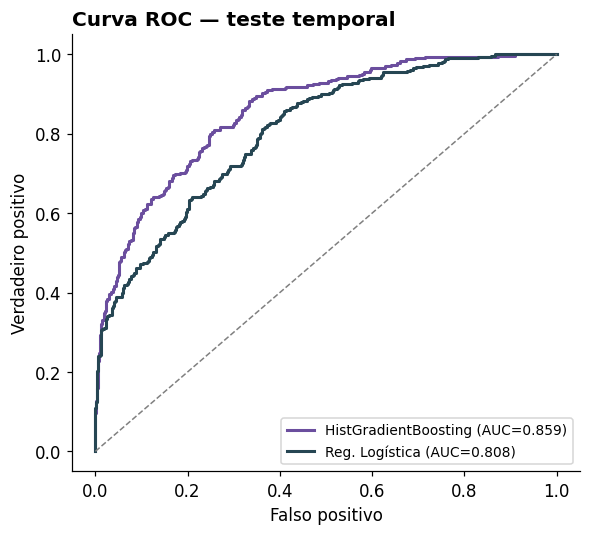

In [4]:
fig,ax=plt.subplots(figsize=(5.5,5))
for nm,cor in [('HistGradientBoosting',ROXO),('Reg. Logística',AZUL)]:
    fpr,tpr,_=roc_curve(yte,res[nm][2]); ax.plot(fpr,tpr,color=cor,lw=2,label=f'{nm} (AUC={res[nm][0]:.3f})')
ax.plot([0,1],[0,1],'--',color='gray',lw=1); ax.set_xlabel('Falso positivo'); ax.set_ylabel('Verdadeiro positivo')
ax.legend(loc='lower right',fontsize=9); ax.set_title('Curva ROC — teste temporal',loc='left',weight='bold'); plt.tight_layout(); plt.show()

## 3. Avaliação do modelo escolhido (HistGradientBoosting)

In [5]:
p=res['HistGradientBoosting'][2]; yhat=(p>=0.5).astype(int)
print(classification_report(yte,yhat,target_names=['sem risco','risco'],digits=3))
cm=confusion_matrix(yte,yhat)
print('Matriz de confusão:\n',cm)
print(f'\nDos {yte.sum()} alunos que realmente caíram, o modelo pegou {cm[1,1]} ({cm[1,1]/yte.sum():.0%}).')

              precision    recall  f1-score   support

   sem risco      0.809     0.796     0.803       457
       risco      0.705     0.721     0.713       308

    accuracy                          0.766       765
   macro avg      0.757     0.759     0.758       765
weighted avg      0.767     0.766     0.766       765

Matriz de confusão:
 [[364  93]
 [ 86 222]]

Dos 308 alunos que realmente caíram, o modelo pegou 222 (72%).


**Estabilidade (5-fold em todos os 1.365 pares).**

In [6]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv=cross_val_score(novo_modelo(),df[FEATURES],df[TARGET],cv=StratifiedKFold(5,shuffle=True,random_state=42),scoring='roc_auc')
print(f'AUC 5-fold: {cv.mean():.3f} ± {cv.std():.3f}')

AUC 5-fold: 0.908 ± 0.010


O teste temporal (0,86) é mais duro que o 5-fold (0,91) justamente por atravessar o deslocamento
entre coortes — e ainda assim o modelo se mantém forte. É a evidência de que **generaliza para um
ano futuro**, não só para uma amostra aleatória.

## 4. Interpretabilidade

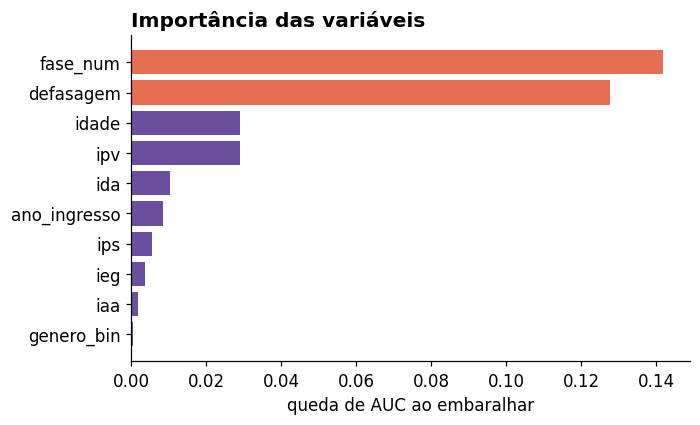

fase_num        0.142
defasagem       0.128
idade           0.029
ipv             0.029
ida             0.010
ano_ingresso    0.008
ips             0.006
ieg             0.004
iaa             0.002
genero_bin      0.001
dtype: float64

In [7]:
from sklearn.inspection import permutation_importance
pi=permutation_importance(hgb,Xte,yte,n_repeats=20,random_state=42,scoring='roc_auc')
imp=pd.Series(pi.importances_mean,index=FEATURES).sort_values()
fig,ax=plt.subplots(figsize=(6.5,4)); ax.barh(imp.index,imp.values,color=[VERM if v>0.05 else ROXO for v in imp.values])
ax.set_xlabel('queda de AUC ao embaralhar'); ax.set_title('Importância das variáveis',loc='left',weight='bold'); plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(3)

**Leitura.** A **posição estrutural** (fase, defasagem atual, idade) domina — coerente: onde o aluno
está hoje é o maior preditor de onde estará. Entre os indicadores comportamentais, o **IPV (ponto de
virada)** lidera. E **gênero é irrelevante (0,001)** — o modelo não discrimina por sexo, um ponto de
equidade importante para uma ONG.

## 5. Calibração e limiar de alerta
Como o app entrega uma *probabilidade*, ela precisa ser confiável, e a ONG precisa escolher **quanto
alertar** conforme sua capacidade de intervenção.

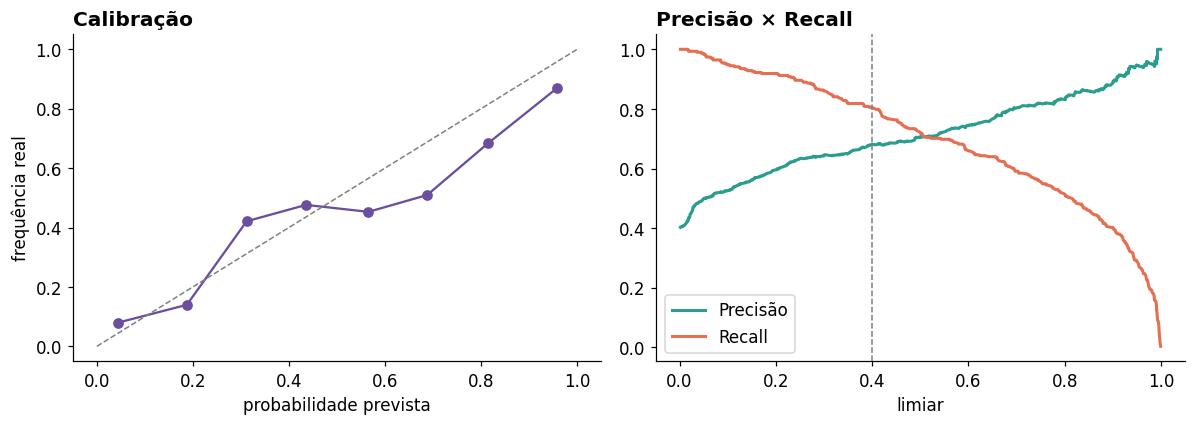

corte 0.3: alerta 411 | precisão 0.64 | recall 0.86
corte 0.4: alerta 364 | precisão 0.68 | recall 0.81
corte 0.5: alerta 315 | precisão 0.70 | recall 0.72
corte 0.6: alerta 272 | precisão 0.75 | recall 0.66


In [8]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve
fig,axes=plt.subplots(1,2,figsize=(11,4))
frac,mean=calibration_curve(yte,p,n_bins=8)
axes[0].plot(mean,frac,'o-',color=ROXO); axes[0].plot([0,1],[0,1],'--',color='gray',lw=1)
axes[0].set_xlabel('probabilidade prevista'); axes[0].set_ylabel('frequência real'); axes[0].set_title('Calibração',loc='left',weight='bold')
prec,rec,thr=precision_recall_curve(yte,p)
axes[1].plot(thr,prec[:-1],color=VERDE,lw=2,label='Precisão'); axes[1].plot(thr,rec[:-1],color=VERM,lw=2,label='Recall')
axes[1].axvline(0.4,ls='--',color='gray',lw=1); axes[1].set_xlabel('limiar'); axes[1].legend(); axes[1].set_title('Precisão × Recall',loc='left',weight='bold')
plt.tight_layout(); plt.show()
for t in [0.3,0.4,0.5,0.6]:
    yh=(p>=t).astype(int); tp=((yh==1)&(yte==1)).sum(); fp=((yh==1)&(yte==0)).sum()
    print(f'corte {t}: alerta {yh.sum():3d} | precisão {tp/(tp+fp):.2f} | recall {tp/yte.sum():.2f}')

Razoavelmente calibrado (leve excesso de confiança na faixa média). Para uso operacional
sugerimos **corte 0,4**: cobre 81% dos casos de risco com 68% de precisão — bom equilíbrio para
priorização com recursos limitados.

## 6. O resultado que importa para a Passos Mágicos
O valor real não está em reconfirmar que quem já está defasado tende a seguir defasado — está em
antecipar quem **está em dia hoje e vai cair**. Avaliamos o modelo só nesse subgrupo.

Alunos em dia em N: 370 | caíram de fato: 84 (23%)
AUC do modelo NESSE subgrupo: 0.867


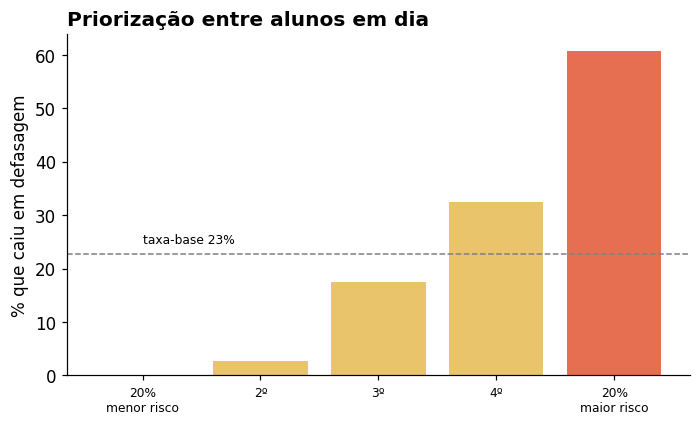

In [9]:
em_dia=df[(df.ano_base==2023)&(df.defasagem>=0)].copy()
em_dia['p']=hgb.predict_proba(em_dia[FEATURES])[:,1]
print(f'Alunos em dia em N: {len(em_dia)} | caíram de fato: {int(em_dia.y_risco.sum())} ({em_dia.y_risco.mean():.0%})')
print(f'AUC do modelo NESSE subgrupo: {roc_auc_score(em_dia.y_risco,em_dia.p):.3f}')
em_dia['q']=pd.qcut(em_dia['p'].rank(method='first'),5,labels=[1,2,3,4,5]).astype(int)
taxa=em_dia.groupby('q')['y_risco'].mean()*100; base_r=em_dia.y_risco.mean()*100
fig,ax=plt.subplots(figsize=(6.5,4)); ax.bar(range(5),[taxa[i] for i in range(1,6)],color=[AMAR]*4+[VERM])
ax.axhline(base_r,ls='--',color='gray',lw=1); ax.text(0,base_r+2,f'taxa-base {base_r:.0f}%',fontsize=8)
ax.set_xticks(range(5)); ax.set_xticklabels(['20%\nmenor risco','2º','3º','4º','20%\nmaior risco'],fontsize=8)
ax.set_ylabel('% que caiu em defasagem'); ax.set_title('Priorização entre alunos em dia',loc='left',weight='bold'); plt.tight_layout(); plt.show()

**Conclusão.** Mesmo restrito a crianças que hoje estão em dia, o modelo alcança **AUC ≈ 0,87** e
produz um gradiente de risco limpo: o quintil de menor risco praticamente não cai, o de maior risco
cai em ~61% — **cerca de 3× a taxa-base**. Traduzindo para a ONG: focar intervenção no grupo de
maior risco previsto multiplica por três a eficiência do uso de recursos.

O mesmo `modelo.py` que treinamos aqui é importado pelo app Streamlit, que treina no startup
(`@st.cache_resource`, sem artefato `.pkl`) e disponibiliza o escore de risco por aluno.